         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

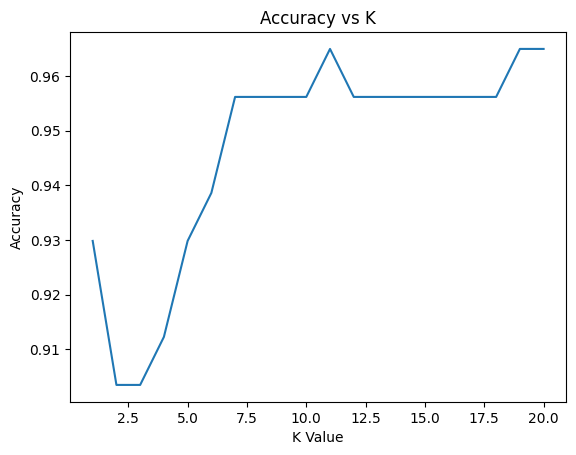

In [1]:
# Student Roll No: XXXXX

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load dataset
df = pd.read_csv("breast-cancer.csv")

# 3. Data inspection
print(df.head())
print(df.info())
print(df.isnull().sum())

# 4. Encode target labels
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])  # M=1, B=0

# 5. Select features
X = df[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']]
y = df['diagnosis']

# 6. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 8. Train KNN with different K
accuracies = []
k_values = range(1, 21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# Best K
best_k = k_values[accuracies.index(max(accuracies))]
print("Best K:", best_k)

# 9. Final Model
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

# 10. Predictions
y_pred = knn.predict(X_test)

# 11. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# 12. Misclassified cases
misclassified = np.where(y_test != y_pred)
print("Misclassified indices:", misclassified)

# Visualization: Accuracy vs K
plt.plot(k_values, accuracies)
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64
Accuracy: 0.7317073170731707
              precision    recall  f1-score   support

           0       0.75      0.29      0.42        41
           1       0.73      0.95      0.83        82

    accuracy                           0.73       123
   macro avg       0.74      0.62      0.62       123
weighted avg       0.74      0.73      0.69       123

Confusion Matrix:
 [[12 29]
 [ 4 78]]
Feature Importance: [0.06371648 0.         0.00661863 0.         0.         0.
 0.05841299 0.0513779  0.03507902 0.02952594 0.73511322 0.02015582]


/tmp/ipykernel_1219/1708099301.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


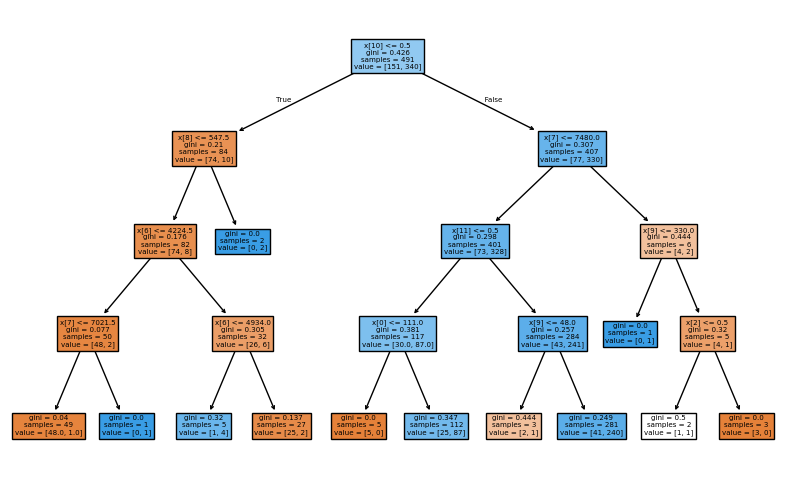

In [2]:
# Student Roll No: XXXXX

# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load dataset
df = pd.read_csv("loan.csv")

# 3. Preprocessing
print(df.isnull().sum())

# Fill missing values
df.fillna(method='ffill', inplace=True)

# Encode categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# 4. Features & Target
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 6. Train Decision Tree
model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train, y_train)

# 7. Predict
y_pred = model.predict(X_test)

# 8. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# 9. Feature Importance
importance = model.feature_importances_
print("Feature Importance:", importance)

# Visualization: Tree
plt.figure(figsize=(10,6))
plot_tree(model, filled=True)
plt.show()